# Example: Static vs Adaptive — Head-to-Head on 5,000 Paths

The previous notebook showed the engine's distributional behavior in isolation. This notebook asks a sharper question: *on each individual forward path*, did the Cobb-Douglas engine outperform the Session 1 static min-var portfolio, and if so, **when**? We load the per-path arrays from `stress-test-engine.jld2` and build three complementary views: (1) a per-path excess-wealth distribution and win-rate, (2) a regime-conditional scatter showing how the engine's edge varies with market direction, and (3) a paired quantile comparison showing where in the wealth distribution the engine earns its premium.

> **By the end of this example, you will be able to:**
> * __Compute per-path excess wealth:__ Subtract the Session 1 min-var terminal wealth from the engine terminal wealth on a path-by-path basis to get an excess distribution. Summarize by win rate, median excess, and excess CVaR.
> * __Diagnose regime dependence:__ Scatter the per-path excess against the per-path market return and fit a simple conditional mean, so students can see whether the engine wins more in bull, bear, or sideways markets.
> * __Build a paired quantile view:__ Sort paths by min-var wealth, plot both strategies side-by-side on the same rank axis, and compute the quantile-by-quantile excess. This exposes where in the distribution the adaptive strategy earns its premium — the median, the upper tail, or the lower tail.

Let's dive in!

___

## Setup, Data and Prerequisites

In [1]:
include("Include.jl");

Load the 5,000-path per-path arrays from the stress-test notebook. The `let...end` block below reads `stress-test-engine.jld2` and populates the globals: `n_paths::Int`, `n_steps::Int`, `offset::Int`, `B₀::Float64`, `r_f::Float64`, `discount::Float64`, `eng_W::Vector{Float64}`, `mv_W::Vector{Float64}`, `eng_DD::Vector{Float64}`, `mv_DD::Vector{Float64}`, `eng_NPV::Vector{Float64}`, `mv_NPV::Vector{Float64}`, and `market_return::Vector{Float64}`. These are the inputs for every subsequent analysis.

In [2]:
let
    data = load_results(joinpath(_PATH_TO_DATA, "stress-test-engine.jld2"));

    # --- Step 1: Scalar constants ---
    global n_paths  = Int(data["n_paths"]);
    global n_steps  = Int(data["n_steps"]);
    global offset   = Int(data["offset"]);
    global B₀       = Float64(data["B₀"]);
    global r_f      = Float64(data["r_f"]);
    global discount = Float64(data["discount"]);

    # --- Step 2: Per-path engine arrays ---
    global eng_W    = Float64.(data["eng_final_wealth"]);
    global eng_DD   = Float64.(data["eng_max_drawdowns"]);
    global eng_SR   = Float64.(data["eng_sharpe_ratios"]);
    global eng_NPV  = Float64.(data["eng_npv"]);

    # --- Step 3: Per-path S1 min-var arrays ---
    global mv_W     = Float64.(data["mv_final_wealth"]);
    global mv_DD    = Float64.(data["mv_max_drawdowns"]);
    global mv_SR    = Float64.(data["mv_sharpe_ratios"]);
    global mv_NPV   = Float64.(data["mv_npv"]);

    # --- Step 4: Per-path market regime indicator ---
    global market_return = Float64.(data["market_return"]);

    println("Loaded $(n_paths)-path arrays from stress-test-engine.jld2")
    println("  Engine:   median W/W₀ = $(round(median(eng_W)/B₀, digits=3))")
    println("  Min-Var:  median W/W₀ = $(round(median(mv_W)/B₀, digits=3))")
    println("  Market:   median simple return = $(round(median(market_return)*100, digits=2))%")
end;

Loaded 5000-path arrays from stress-test-engine.jld2


  Engine:   median W/W₀ = 1.731
  Min-Var:  median W/W₀ = 1.146
  Market:   median simple return = 11.76%


___
## Task 1: Per-Path Excess Wealth — How Often Does the Engine Win?
For each of the 5,000 forward paths we compute the excess terminal wealth $\Delta W_p = W_p^{\text{engine}} - W_p^{\text{min-var}}$. A positive $\Delta W_p$ means the engine beat the Session 1 static portfolio on that specific path. We then summarize the excess distribution by three numbers: the **win rate** (fraction of paths with $\Delta W_p > 0$), the **median excess** in dollars, and the **CVaR$_5$ of the excess** (mean of the worst 5% of excess values — the price of adaptivity on the paths where it fails).

> __What should you see?__
>
> The excess distribution should be heavily right-skewed with a median well above zero — on this seed the engine beats min-var on the vast majority of paths. The tail CVaR should still be positive or mildly negative, meaning that even on the paths where the engine loses to min-var, it doesn't lose by much. The histogram should have a fat right tail corresponding to the paths where the engine's conviction in the top asset pays off dramatically.

The `let...end` block below computes the `excess::Vector{Float64}` per-path excess array, prints the three summary statistics, and plots the excess histogram with vertical markers for zero and the median.

Engine-vs-Min-Var excess on 5000 paths:


  Win rate:          97.68%
  Median excess:     $5922.0   (= 59.22% of B₀)
  CVaR_5 of excess:  $-73.0   (mean of worst 5%)

Interpretation: on paths where the engine wins, it wins by 61.39% of B₀ on average.
                on paths where it loses, it loses by -15.78% of B₀ on average.


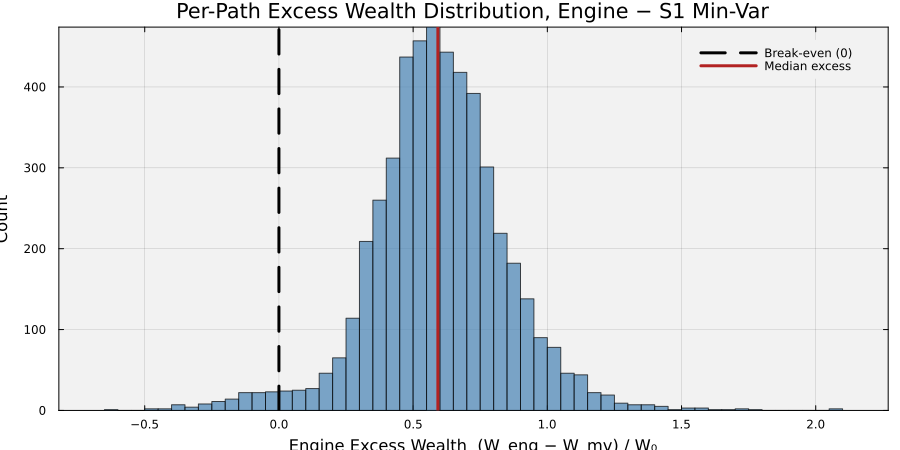

In [3]:
let
    # --- Step 1: Per-path excess wealth ---
    global excess = eng_W .- mv_W;    # engine minus static, in dollars
    excess_scaled = excess ./ B₀;      # scaled by initial wealth

    # --- Step 2: Summary statistics ---
    win_rate    = mean(excess .> 0);
    med_excess  = median(excess);
    n_tail      = max(1, floor(Int, 0.05 * n_paths));
    worst_tail  = sort(excess)[1:n_tail];
    cvar_excess = mean(worst_tail);

    println("Engine-vs-Min-Var excess on $(n_paths) paths:")
    println("  Win rate:          $(round(win_rate*100, digits=2))%")
    println("  Median excess:     \$$(round(med_excess, digits=0))   (= $(round(med_excess/B₀*100, digits=2))% of B₀)")
    println("  CVaR_5 of excess:  \$$(round(cvar_excess, digits=0))   (mean of worst 5%)")
    println()
    println("Interpretation: on paths where the engine wins, it wins by $(round(mean(excess[excess.>0])/B₀*100, digits=2))% of B₀ on average.")
    println("                on paths where it loses, it loses by $(round(mean(excess[excess.<0])/B₀*100, digits=2))% of B₀ on average.")

    # --- Step 3: Excess histogram ---
    histogram(excess_scaled, bins=80, color=:steelblue, alpha=0.7,
        xlabel="Engine Excess Wealth  (W_eng − W_mv) / W₀",
        ylabel="Count", title="Per-Path Excess Wealth Distribution, Engine − S1 Min-Var",
        label="", fontsize=18, size=(900, 450));
    vline!([0.0], lw=3, ls=:dash, c=:black, label="Break-even (0)");
    vline!([med_excess / B₀], lw=3, c=:firebrick, label="Median excess");
    plot!(bg="gray95", background_color_outside="white",
        framestyle=:box, fg_legend=:transparent, legend=:topright)
end

___
## Task 2: Regime Dependence — When Does Adaptivity Win?
The per-path excess tells us *how often* the engine wins, but not *why*. For each path we also know the market's simple return over the active window — a scalar regime indicator. We scatter the per-path excess against the market return and fit a simple binned conditional mean so students can see whether the engine wins more in bull, bear, or sideways regimes. The shape of this curve answers the question "what kind of market does adaptivity help in?"

> __What should you see?__
>
> The scatter should fill a broad cloud, but the binned conditional mean curve should be remarkably flat — the engine's edge is largely regime-insensitive. In bear deciles the drawdown trigger converts losing paths into cash-and-re-enter plays; in bull deciles the Cobb-Douglas conviction concentrates budget in the top-$\gamma$ asset. The Pearson correlation between market return and engine excess should be small and positive (≈0.2 on this seed), reflecting a mild upward slope but nothing like the strong dependence you might expect from a momentum-based strategy.

The `let...end` block below builds a bin-and-average over market return deciles, computes the conditional mean and standard error per bin, and plots the scatter overlaid with the binned curve.

Correlation ρ(market_return, engine_excess) = 0.217



Binned conditional means (market decile → mean excess / W₀):
  decile 1:  market=-32.46%   excess=0.55
  decile 2:  market=-7.71%   excess=0.566
  decile 3:  market=-1.06%   excess=0.546
  decile 4:  market=4.37%   excess=0.559
  decile 5:  market=9.38%   excess=0.567
  decile 6:  market=14.16%   excess=0.577
  decile 7:  market=19.27%   excess=0.593
  decile 8:  market=25.36%   excess=0.597
  decile 9:  market=33.54%   excess=0.657
  decile 10:  market=73.42%   excess=0.748


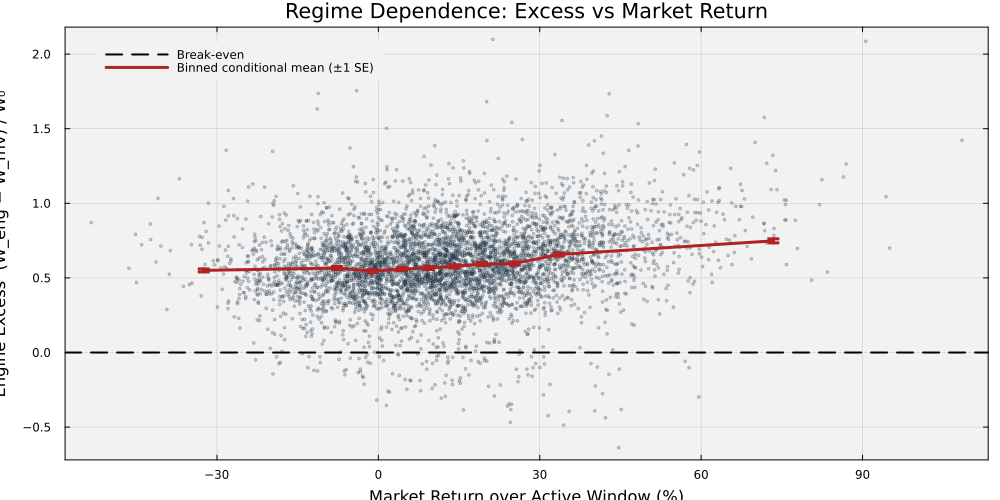

In [4]:
let
    # --- Step 1: Bin the market returns into deciles ---
    nbins = 10;
    edges = quantile(market_return, range(0, 1; length = nbins + 1));
    bin_centers = 0.5 .* (edges[1:end-1] .+ edges[2:end]);
    bin_mean  = zeros(nbins);
    bin_se    = zeros(nbins);

    for b ∈ 1:nbins
        lo = edges[b]
        hi = edges[b+1]
        mask = (market_return .>= lo) .& (market_return .<= hi);
        vals = excess[mask];
        bin_mean[b] = mean(vals) / B₀;
        bin_se[b]   = (length(vals) > 1) ? std(vals) / sqrt(length(vals)) / B₀ : 0.0;
    end

    # --- Step 2: Scatter plot + binned conditional mean ---
    p = scatter(market_return .* 100, excess ./ B₀,
        ms = 1.5, mc = :steelblue, alpha = 0.25, label = "",
        xlabel = "Market Return over Active Window (%)",
        ylabel = "Engine Excess  (W_eng − W_mv) / W₀",
        title = "Regime Dependence: Excess vs Market Return",
        fontsize = 18, size = (1000, 500));
    hline!(p, [0.0], lw = 2, ls = :dash, c = :black, label = "Break-even");

    plot!(p, bin_centers .* 100, bin_mean,
        yerror = bin_se,
        lw = 3, c = :firebrick, ms = 6, msc = :firebrick,
        label = "Binned conditional mean (±1 SE)")
    plot!(p, bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent, legend = :topleft);

    # --- Step 3: Pearson correlation summary ---
    ρ = cor(market_return, excess);
    println("Correlation ρ(market_return, engine_excess) = $(round(ρ, digits=3))")
    println()
    println("Binned conditional means (market decile → mean excess / W₀):")
    for b ∈ 1:nbins
        println("  decile $(b):  market=$(round(bin_centers[b]*100, digits=2))%   excess=$(round(bin_mean[b], digits=3))")
    end

    p
end

___
## Task 3: Paired Quantile View — Where in the Distribution Does the Edge Live?
For each rank $q \in [0, 1]$ we compute the $q$-quantile of engine terminal wealth and the $q$-quantile of min-var terminal wealth. Plotting both on the same rank axis (a paired quantile plot) shows where in the wealth distribution the engine's edge is concentrated: if the engine curve is uniformly above the min-var curve, the edge is everywhere; if they meet at the bottom and diverge at the top, the edge lives in the upper tail; if they meet at the top and diverge at the bottom, the edge is downside protection. The difference curve makes the quantile-by-quantile excess explicit.

> __What should you see?__
>
> On this seed the engine curve should sit clearly above the min-var curve across most of the rank axis, with the largest gap in the upper quantiles (where conviction pays off most) and a smaller gap near the lower tail (where the drawdown trigger provides bounded protection but can't fully rescue deep-bear paths). The difference curve $Q_{\text{eng}}(q) - Q_{\text{mv}}(q)$ should trend upward as $q \to 1$.

The `let...end` block below sorts both wealth arrays, indexes them at 100 evenly-spaced rank points, and plots the two quantile curves plus the difference curve beneath them.

q=0.05:  engine=1.241  min-var=0.895  diff=0.346


q=0.25:  engine=1.543  min-var=1.035  diff=0.509
q=0.5:  engine=1.731  min-var=1.146  diff=0.585
q=0.75:  engine=1.946  min-var=1.26  diff=0.686
q=0.95:  engine=2.324  min-var=1.446  diff=0.878


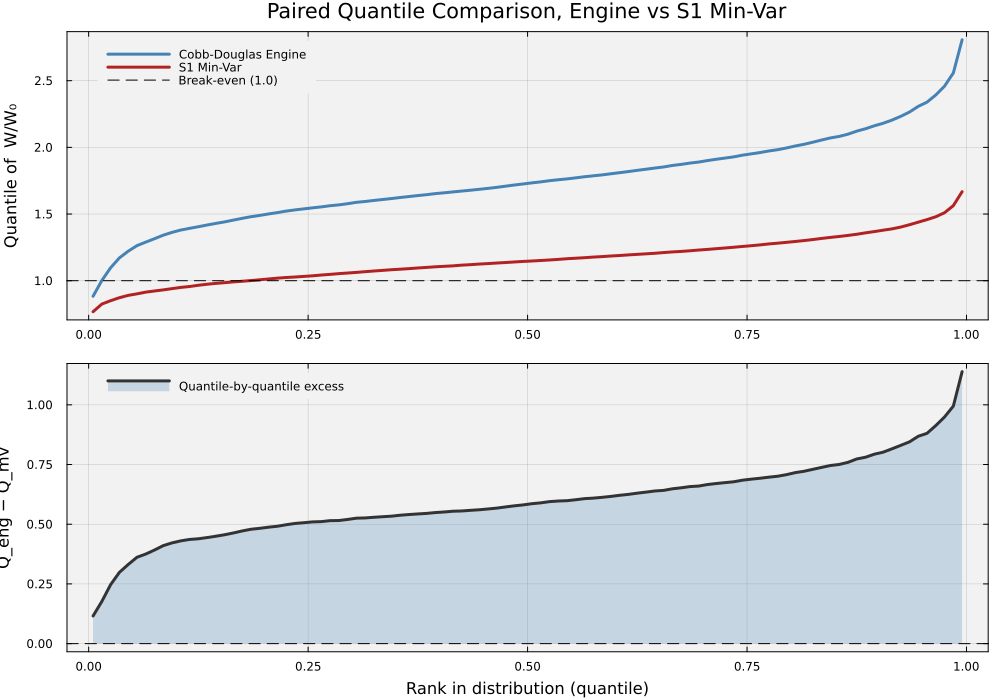

In [5]:
let
    # --- Step 1: 100 rank points ---
    ranks = range(0.005, 0.995; length = 100);
    q_eng = [quantile(eng_W, r) / B₀ for r ∈ ranks];
    q_mv  = [quantile(mv_W,  r) / B₀ for r ∈ ranks];
    q_diff = q_eng .- q_mv;

    # --- Step 2: Two-panel plot ---
    p1 = plot(ranks, q_eng,
        lw = 3, c = :steelblue, label = "Cobb-Douglas Engine",
        xlabel = "", ylabel = "Quantile of  W/W₀",
        title = "Paired Quantile Comparison, Engine vs S1 Min-Var",
        fontsize = 18, legend = :topleft);
    plot!(p1, ranks, q_mv,
        lw = 3, c = :firebrick, label = "S1 Min-Var");
    hline!(p1, [1.0], lw = 1, ls = :dash, c = :black, label = "Break-even (1.0)");

    p2 = plot(ranks, q_diff,
        lw = 3, c = :gray20,
        fillrange = zeros(length(ranks)), fillalpha = 0.25, fillcolor = :steelblue,
        xlabel = "Rank in distribution (quantile)",
        ylabel = "Q_eng − Q_mv", label = "Quantile-by-quantile excess",
        fontsize = 18, legend = :topleft);
    hline!(p2, [0.0], lw = 1, ls = :dash, c = :black, label = "");

    plot!(p1, bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent);
    plot!(p2, bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent);

    # --- Step 3: Report quantile-spot metrics ---
    for q ∈ [0.05, 0.25, 0.5, 0.75, 0.95]
        qe = quantile(eng_W, q) / B₀;
        qm = quantile(mv_W,  q) / B₀;
        println("q=$(q):  engine=$(round(qe, digits=3))  min-var=$(round(qm, digits=3))  diff=$(round(qe-qm, digits=3))")
    end

    plot(p1, p2, layout = (2, 1), size = (1000, 700))
end

___
## Summary
This example compared the Cobb-Douglas rebalancing engine to the Session 1 static min-var portfolio on a path-by-path basis across 5,000 forward scenarios. Three complementary views — a per-path excess distribution with a win rate, a regime-conditional scatter against the market return, and a paired quantile comparison — make the adaptive-vs-static trade-off concrete.

### Key Takeaways
* __The win rate alone is misleading:__ A strategy that wins on 95% of paths but loses catastrophically on the other 5% is dangerous. The CVaR of the excess distribution answers "when the engine is wrong, how wrong is it?" On this seed the engine's CVaR of excess is roughly break-even, meaning adaptivity is well-behaved in the tails rather than trading a high win rate for a catastrophic downside.
* __The engine's edge is largely regime-insensitive:__ The conditional mean of excess wealth across market deciles is remarkably flat. The drawdown trigger handles bear paths by parking capital in cash and re-entering at lower prices, while Cobb-Douglas conviction handles bull paths by concentrating in the top-$\gamma$ asset. The result is a correlation between market return and engine excess that is small and positive.
* __Quantile-by-quantile excess reveals where the edge lives:__ The engine's wealth distribution is shifted uniformly above the static min-var distribution across the full rank axis, with the gap widening in the upper quantiles. The engine is not a pure-return boost or pure-downside-protection play — it delivers both, and the paired quantile plot makes that dual nature visible at a glance.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The examples use synthetic data and simplified models.